In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,roc_auc_score,accuracy_score,precision_score,recall_score,f1_score

In [2]:
df = pd.read_excel("HotelData.xlsx")

In [3]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled


In [4]:
df['type_of_meal_plan'].value_counts()

type_of_meal_plan
Meal Plan 1     20265
Not Selected     4463
Meal Plan 2      1078
Meal Plan 3         5
Name: count, dtype: int64

In [5]:
df['required_car_parking_space'].value_counts()

required_car_parking_space
0    24716
1     1095
Name: count, dtype: int64

In [6]:
df['arrival_year'].value_counts()

arrival_year
2018    21952
2017     3859
Name: count, dtype: int64

In [7]:
df.dtypes

no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                           object
dtype: object

In [8]:
df.shape

(25811, 16)

In [9]:
df.isnull().sum()

no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [10]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000
mean,1.890744,0.142265,0.883034,2.263918,0.042424,65.548836,2017.850490,7.331099,15.752780,0.033009,0.028747,0.214676,105.747677,0.746426
std,0.529264,0.464034,0.887990,1.514417,0.201558,67.452796,0.356597,3.143281,8.854341,0.178664,0.410378,2.075722,37.916084,0.815896
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,12.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.750000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,44.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,100.000000,1.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,98.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,127.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [11]:
df.describe(include="object")

,type_of_meal_plan,booking_status
count,25811,25811
unique,4,2
top,Meal Plan 1,Not_Canceled
freq,20265,18542


In [12]:
df["booking_status"].value_counts()

booking_status
Not_Canceled    18542
Canceled         7269
Name: count, dtype: int64

In [13]:
df['total_guests'] = df["no_of_adults"] + df["no_of_children"]

In [14]:
df['total_nights'] = df["no_of_weekend_nights"] + df["no_of_week_nights"]

In [16]:
df['booking_status'].value_counts(normalize=True)

booking_status
Not_Canceled    0.718376
Canceled        0.281624
Name: proportion, dtype: float64

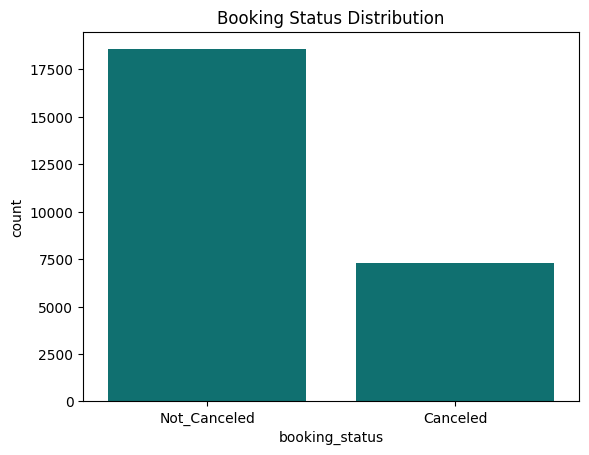

In [17]:
sns.countplot(data=df,x="booking_status",color="teal")
plt.title("Booking Status Distribution")
plt.show()

In [18]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

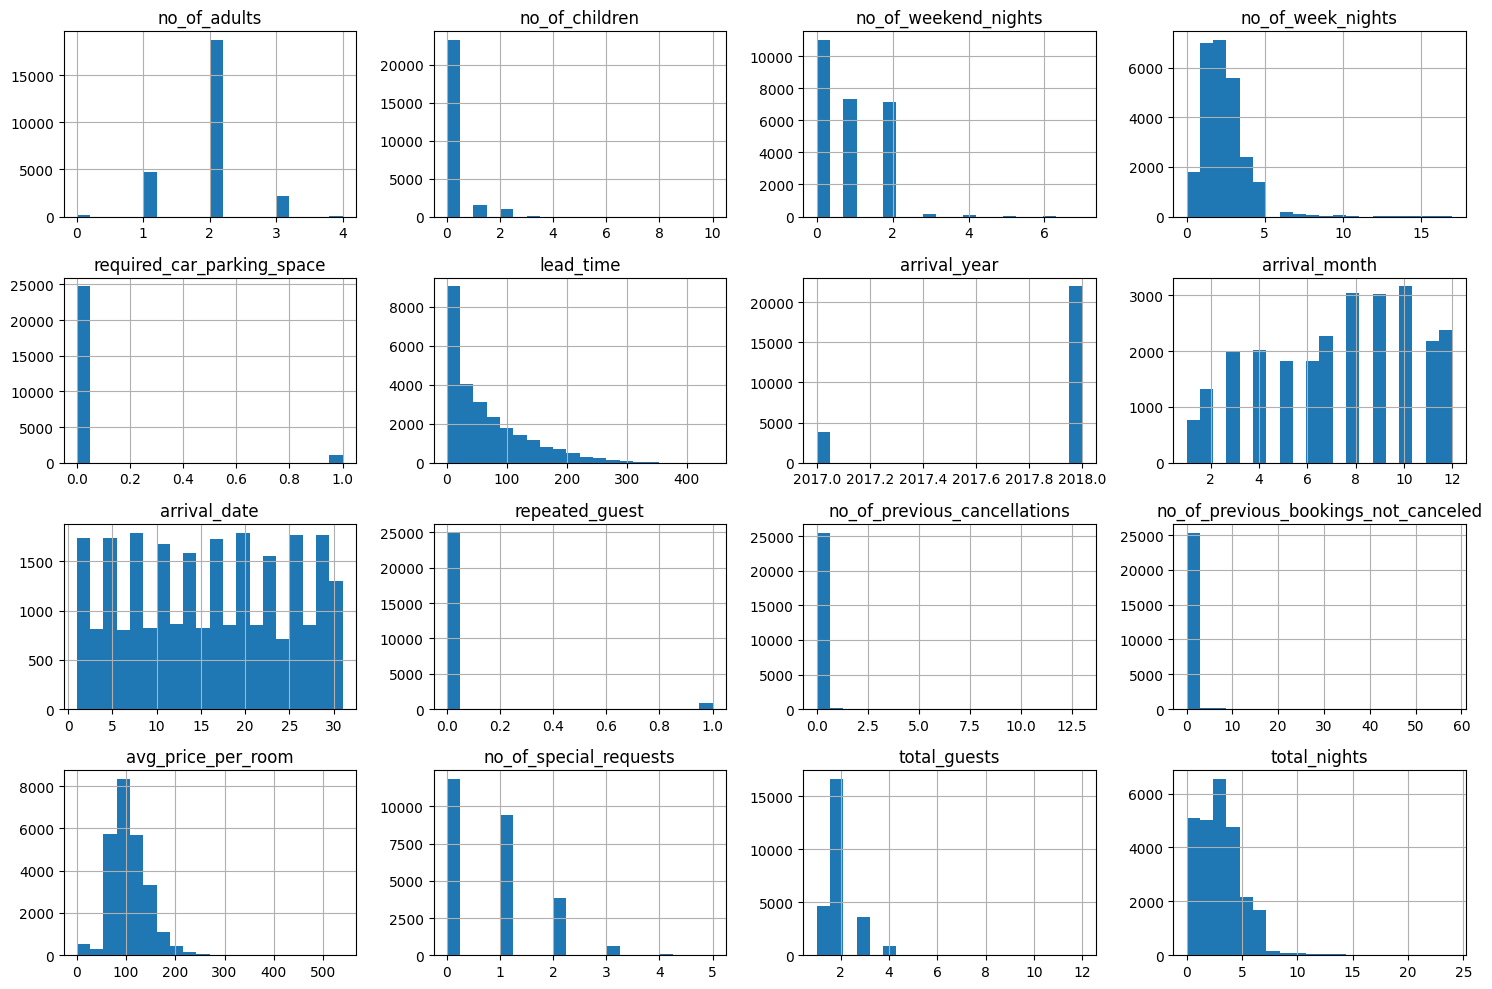

In [19]:
df[num_cols].hist(figsize=(15,10),bins=20)
plt.tight_layout()
plt.show()

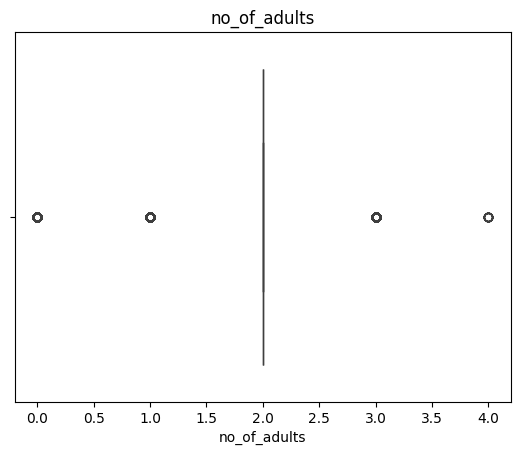

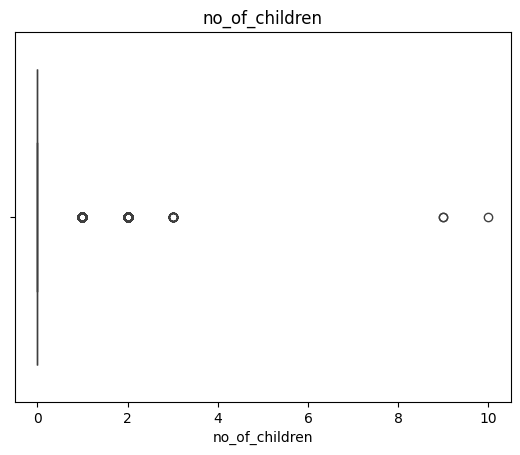

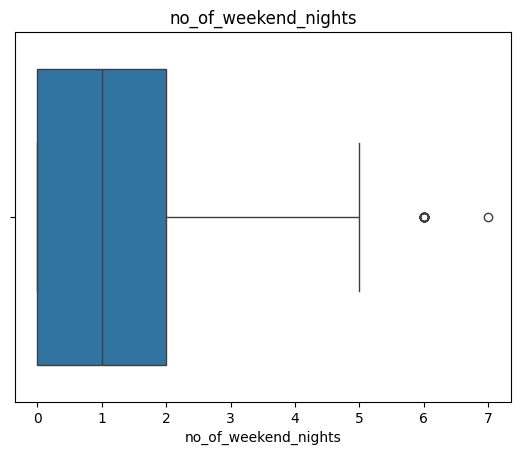

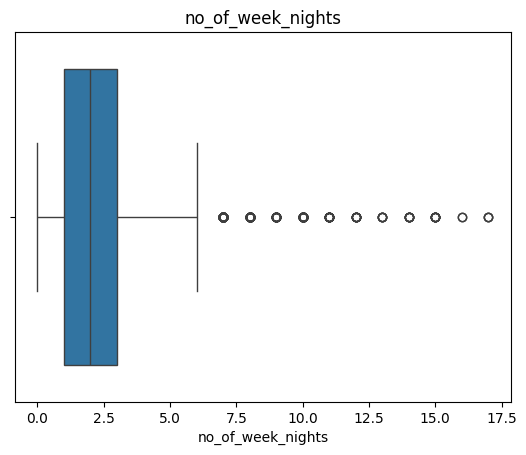

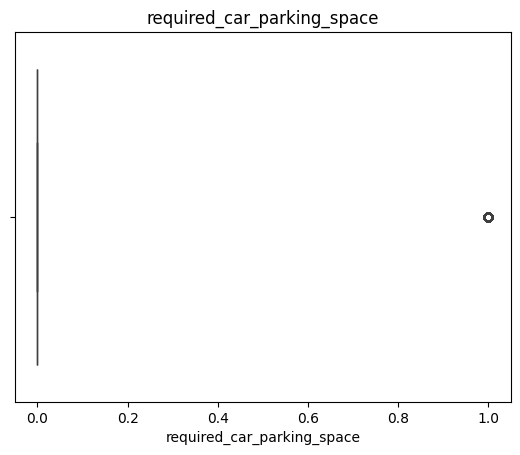

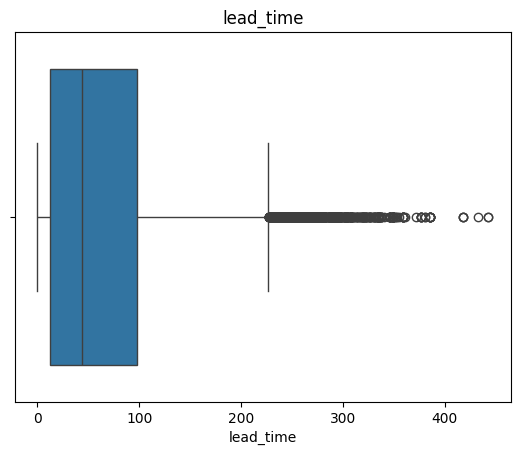

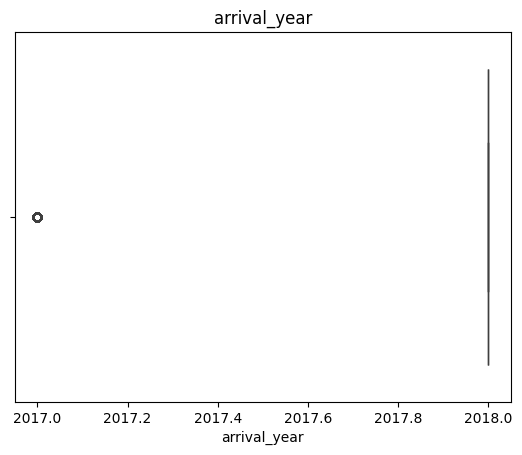

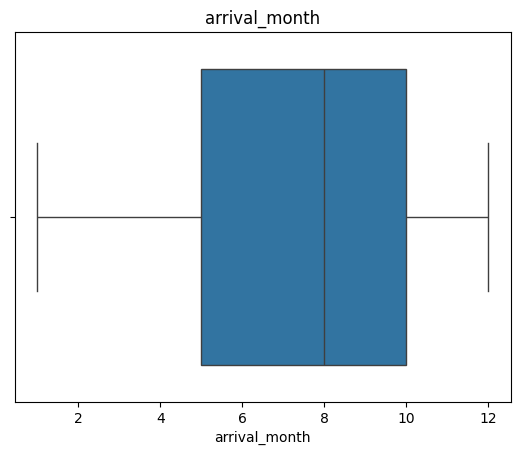

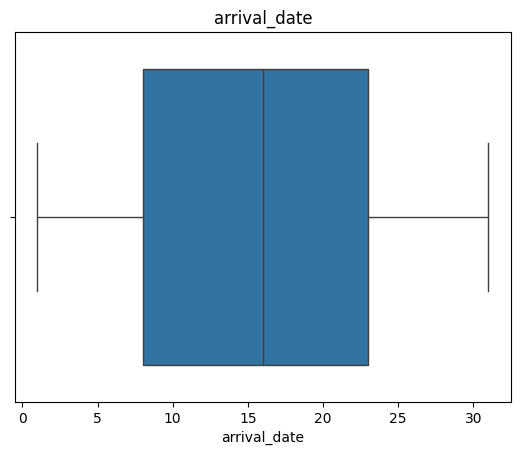

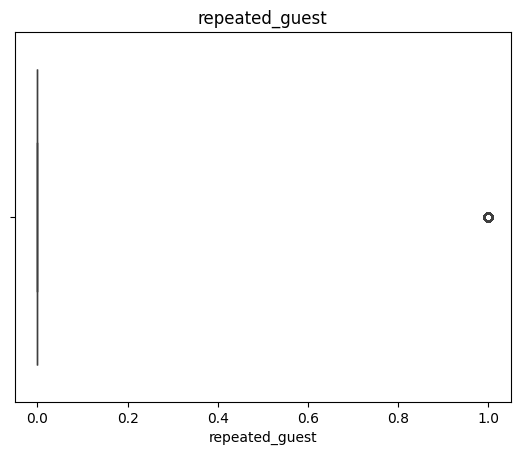

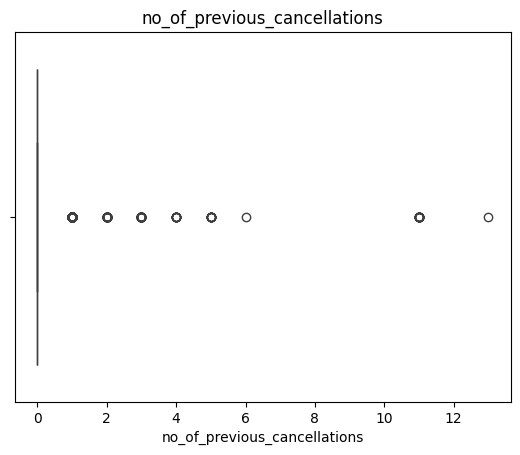

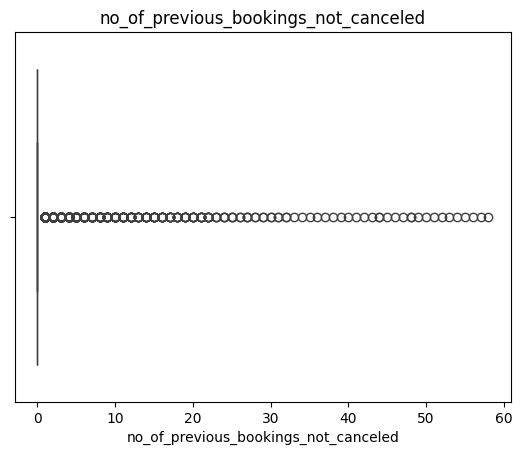

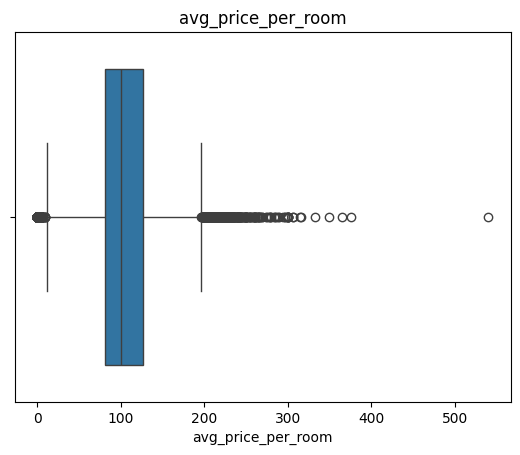

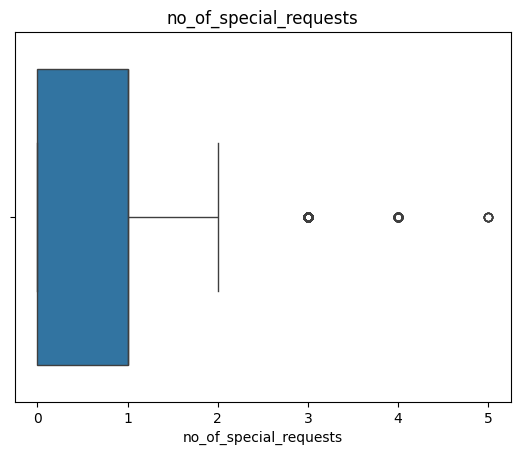

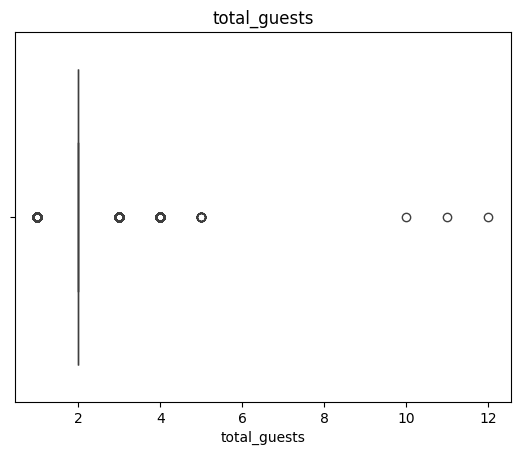

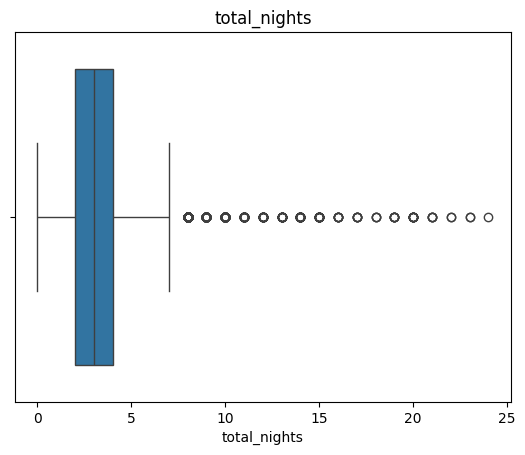

In [20]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [21]:
df.groupby("booking_status")["lead_time"].mean()

booking_status
Canceled        104.366488
Not_Canceled     50.331194
Name: lead_time, dtype: float64

In [22]:
df.groupby("booking_status")["avg_price_per_room"].mean()

booking_status
Canceled        115.347719
Not_Canceled    101.984183
Name: avg_price_per_room, dtype: float64

In [23]:
df.groupby("booking_status")["total_guests"].mean()

booking_status
Canceled        2.163434
Not_Canceled    1.981879
Name: total_guests, dtype: float64

In [24]:
df['type_of_meal_plan'].value_counts()

type_of_meal_plan
Meal Plan 1     20265
Not Selected     4463
Meal Plan 2      1078
Meal Plan 3         5
Name: count, dtype: int64

In [25]:
pivot_price = pd.pivot_table(df,values="avg_price_per_room",index="arrival_month",columns="booking_status",aggfunc="mean")

In [26]:
pivot_price

booking_status,Canceled,Not_Canceled
arrival_month,,
1,80.712500,74.699604
2,85.791088,81.922206
3,102.712011,88.245341
4,114.445248,101.441568
5,127.641138,114.316431
6,121.214241,110.758705
7,116.580144,113.607542
8,120.482596,113.883753
9,128.644103,116.043386


In [27]:
pd.pivot_table(df,values="no_of_adults",index="arrival_month",columns="booking_status",aggfunc="count")

booking_status,Canceled,Not_Canceled
arrival_month,,
1,16,758
2,285,1029
3,542,1436
4,625,1397
5,571,1261
6,573,1251
7,903,1371
8,1198,1844
9,853,2168


In [28]:
cancel_rate = df.groupby("arrival_month")["booking_status"].apply(lambda x:(x=="Canceled").mean())

In [29]:
cancel_rate

arrival_month
1     0.020672
2     0.216895
3     0.274014
4     0.309100
5     0.311681
6     0.314145
7     0.397098
8     0.393820
9     0.282357
10    0.276178
11    0.224154
12    0.142677
Name: booking_status, dtype: float64

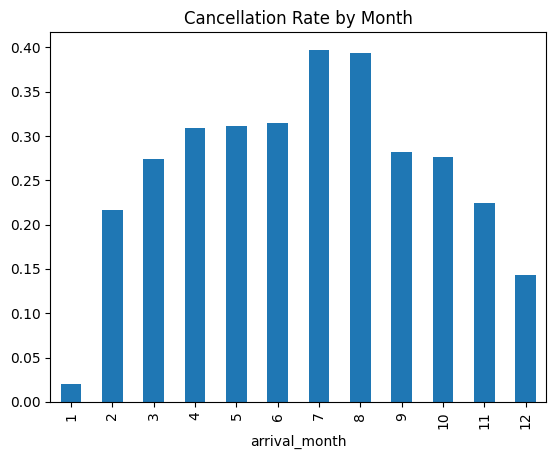

In [30]:
cancel_rate.plot(kind="bar",title="Cancellation Rate by Month")
plt.show()

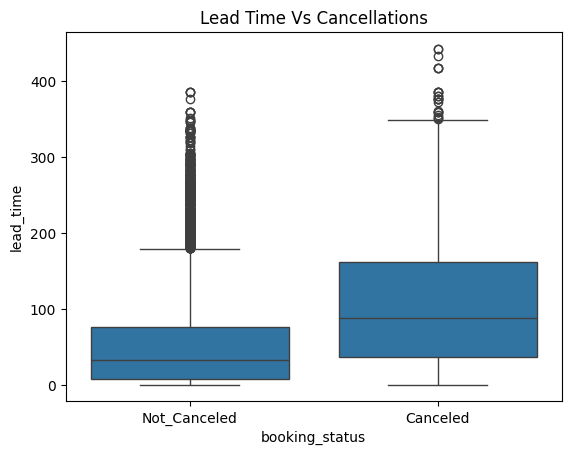

In [31]:
sns.boxplot(data=df,x="booking_status",y="lead_time")
plt.title("Lead Time Vs Cancellations")
plt.show()

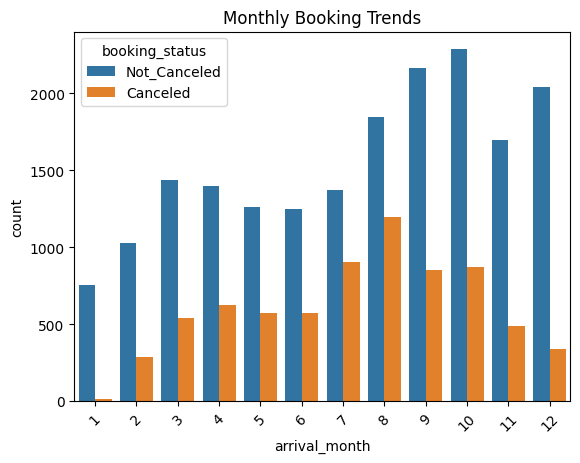

In [32]:
sns.countplot(data=df,x="arrival_month",hue="booking_status")
plt.title("Monthly Booking Trends")
plt.xticks(rotation=45)
plt.show()

In [33]:
df["booking_status"] = df["booking_status"].map({
    "Not_Canceled":1,
    "Canceled":0
})

In [34]:
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests,total_nights
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,1,2,3
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,1,2,5
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,0,1,3
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,0,2,2
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25806,2,2,0,1,Meal Plan 1,0,0,2018,10,6,0,0,0,216.00,0,0,4,1
25807,3,0,2,6,Meal Plan 1,0,85,2018,8,3,0,0,0,167.80,1,1,3,8
25808,2,0,1,3,Meal Plan 1,0,228,2018,10,17,0,0,0,90.95,2,0,2,4
25809,2,0,2,6,Meal Plan 1,0,148,2018,7,1,0,0,0,98.39,2,1,2,8


In [35]:
df = pd.get_dummies(df,columns=['type_of_meal_plan'],drop_first=True,dtype=int)

In [36]:
df.columns.tolist()

['no_of_adults',
 'no_of_children',
 'no_of_weekend_nights',
 'no_of_week_nights',
 'required_car_parking_space',
 'lead_time',
 'arrival_year',
 'arrival_month',
 'arrival_date',
 'repeated_guest',
 'no_of_previous_cancellations',
 'no_of_previous_bookings_not_canceled',
 'avg_price_per_room',
 'no_of_special_requests',
 'booking_status',
 'total_guests',
 'total_nights',
 'type_of_meal_plan_Meal Plan 2',
 'type_of_meal_plan_Meal Plan 3',
 'type_of_meal_plan_Not Selected']

In [37]:
X = df.drop(["no_of_adults","no_of_children","no_of_weekend_nights","no_of_week_nights","booking_status"],axis=1)

In [38]:
X

,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,total_guests,total_nights,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected
0,0,224,2017,10,2,0,0,0,65.00,0,2,3,0,0,0
1,0,5,2018,11,6,0,0,0,106.68,1,2,5,0,0,1
2,0,1,2018,2,28,0,0,0,60.00,0,1,3,0,0,0
3,0,211,2018,5,20,0,0,0,100.00,0,2,2,0,0,0
4,0,48,2018,4,11,0,0,0,94.50,0,2,2,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25806,0,0,2018,10,6,0,0,0,216.00,0,4,1,0,0,0
25807,0,85,2018,8,3,0,0,0,167.80,1,3,8,0,0,0
25808,0,228,2018,10,17,0,0,0,90.95,2,2,4,0,0,0
25809,0,148,2018,7,1,0,0,0,98.39,2,2,8,0,0,0


In [39]:
y = df["booking_status"]

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [42]:
y.value_counts()

booking_status
1    18542
0     7269
Name: count, dtype: int64

In [43]:
from sklearn.utils.class_weight import compute_class_weight

In [44]:
import numpy as np
classes = np.unique(y_train)

In [45]:
classes

array([0, 1], dtype=int64)

In [46]:
weights = compute_class_weight(class_weight="balanced",classes=classes,y=y_train)

In [47]:
weights

array([1.77540843, 0.69601564])

In [48]:
class_weights = dict(zip(classes,weights))

In [49]:
class_weights

{0: 1.775408426483233, 1: 0.6960156408009168}

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [51]:
rf = RandomForestClassifier(class_weight = class_weights)

In [52]:
rf_params = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [53]:
rf_random = RandomizedSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=1
)


In [54]:
rf_random.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight={0: 1.775408426483233,
                                                                  1: 0.6960156408009168}),
                   n_jobs=1,
                   param_distributions={'max_depth': [5, 10, 20, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   scoring='f1')

In [55]:
rf_random.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_depth': None}

In [56]:
from sklearn.ensemble import GradientBoostingClassifier

gb=GradientBoostingClassifier()

In [57]:
gb_params = {
    "n_estimators":[100,200],
    "learning_rate":[0.01,0.1,0.2],
    "max_depth":[3,5,7]
}


In [58]:
gb_random = RandomizedSearchCV(
    gb,
    gb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [59]:
gb_random.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200]},
                   scoring='f1')

In [60]:
from sklearn.linear_model import LogisticRegression
lr =  LogisticRegression()

In [64]:
lr_params = {
    'C':[0.01,0.1,0.2],
    'solver':["liblinear"],
    'penalty':['l1','l2'],
    'max_iter':[100,200,300]
}

In [65]:
lr_random = RandomizedSearchCV(
    lr,
    lr_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [66]:
lr_random.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
                   param_distributions={'C': [0.01, 0.1, 0.2],
                                        'max_iter': [100, 200, 300],
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear']},
                   scoring='f1')

In [67]:
models = {
    "RandomForestClassifier":rf_random.best_estimator_,
    "GradientBoosting":gb_random.best_estimator_,
    "LogisticRegression":lr_random.best_estimator_
}

In [68]:
from sklearn.metrics import accuracy_score

RandomForestClassifier
ROC-AUC  : 0.8931331943601255
0.8363354638775905
              precision    recall  f1-score   support

           0       0.73      0.66      0.69      1454
           1       0.87      0.90      0.89      3709

    accuracy                           0.84      5163
   macro avg       0.80      0.78      0.79      5163
weighted avg       0.83      0.84      0.83      5163



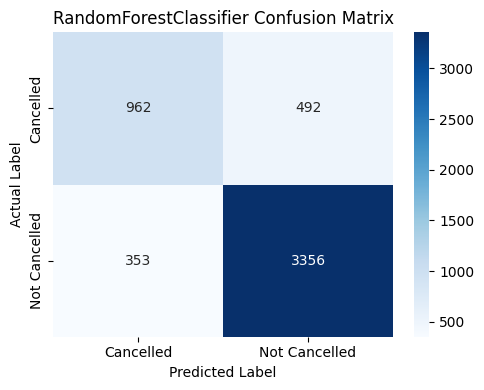

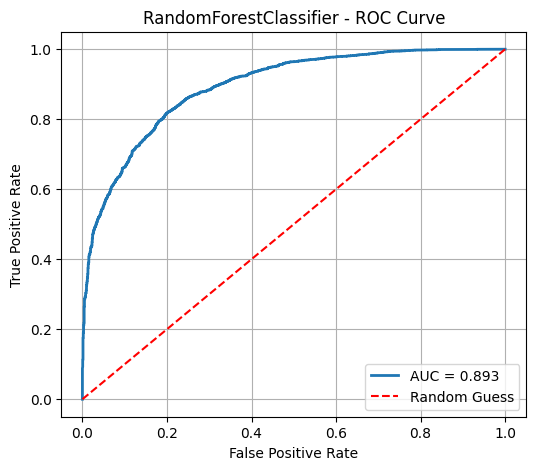

************************************************************
GradientBoosting
ROC-AUC  : 0.8985046225712912
0.8462134417974047
              precision    recall  f1-score   support

           0       0.77      0.64      0.70      1454
           1       0.87      0.93      0.90      3709

    accuracy                           0.85      5163
   macro avg       0.82      0.78      0.80      5163
weighted avg       0.84      0.85      0.84      5163



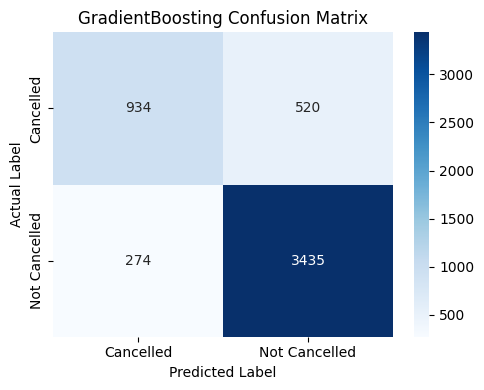

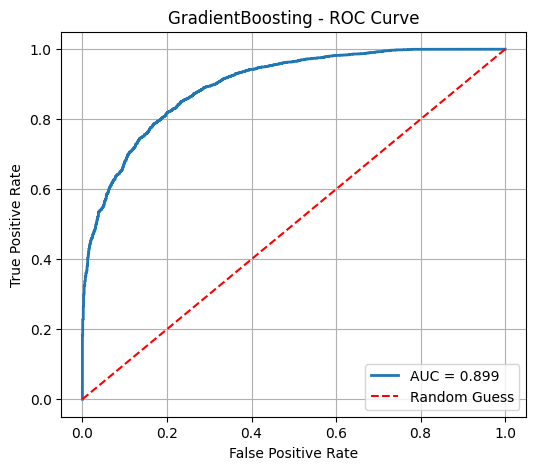

************************************************************
LogisticRegression
ROC-AUC  : 0.8226889090553741
0.7900445477435599
              precision    recall  f1-score   support

           0       0.69      0.46      0.56      1454
           1       0.81      0.92      0.86      3709

    accuracy                           0.79      5163
   macro avg       0.75      0.69      0.71      5163
weighted avg       0.78      0.79      0.78      5163



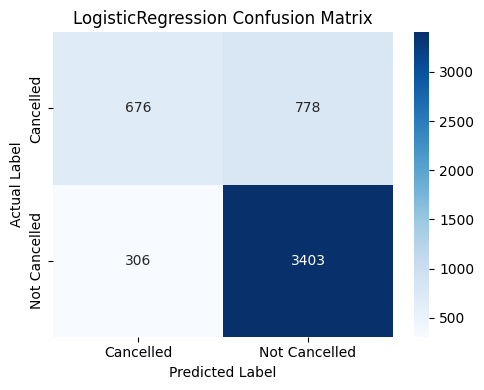

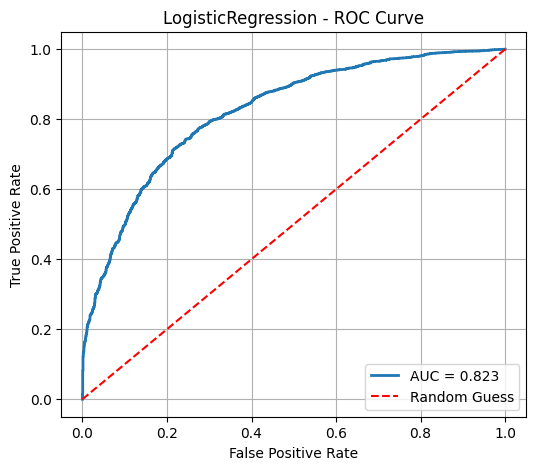

************************************************************


In [70]:
for name,model in models.items():
    print(f"{name}")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
    print(accuracy_score(y_test,y_pred))
    print(classification_report(y_test,y_pred))
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test,y_pred),
                cmap="Blues",
                fmt="d",
                annot=True,
               xticklabels=["Cancelled","Not Cancelled"],
               yticklabels=[ "Cancelled","Not Cancelled"])
    
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

    fpr, tpr, threshold = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(6,5))

    plt.plot(fpr, tpr,
             linewidth=2,
             label=f"AUC = {auc:.3f}")

    plt.plot([0,1], [0,1], "r--", label="Random Guess")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.show()

    print("*" * 60)
    

In [77]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


In [78]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

In [79]:
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,GradientBoosting,0.846213,0.868521,0.926126,0.896399,0.898505
1,RandomForestClassifier,0.836335,0.872141,0.904826,0.888183,0.893133
2,LogisticRegression,0.790045,0.813920,0.917498,0.862611,0.822689


In [84]:
rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=1,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(min_samples_split=5, n_jobs=-1, random_state=42)

In [87]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)



In [90]:
importance.head(10).reset_index(drop=True)

,Feature,Importance
0,lead_time,0.306013
1,avg_price_per_room,0.206062
2,no_of_special_requests,0.125297
3,arrival_date,0.103918
4,arrival_month,0.091547
5,total_nights,0.068675
6,total_guests,0.029398
7,arrival_year,0.026264
8,type_of_meal_plan_Not Selected,0.017216
9,required_car_parking_space,0.010091


In [91]:
top_features = [
    "lead_time",
    "avg_price_per_room",
    "no_of_special_requests",
    "arrival_date",
    "arrival_month",
    "total_nights",
    "total_guests",
    "arrival_year",
    "type_of_meal_plan_Not Selected",
    "required_car_parking_space"
]

In [92]:
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

In [93]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train_top, y_train)

y_pred = gb.predict(X_test_top)
y_prob = gb.predict_proba(X_test_top)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy : 0.8268448576409064
ROC-AUC  : 0.8792518514205565
              precision    recall  f1-score   support

           0       0.75      0.58      0.65      1454
           1       0.85      0.92      0.88      3709

    accuracy                           0.83      5163
   macro avg       0.80      0.75      0.77      5163
weighted avg       0.82      0.83      0.82      5163



In [97]:
joblib.dump(top_features, "top_features.pkl")

['top_features.pkl']

In [105]:
import joblib

joblib.dump(gb, "hotel_booking_model_new.pkl")

print("Model saved successfully")

Model saved successfully
